# Data Analytics Internship Project: Supply Chain & Logistics Optimization
## Organization: CodeAlpha

## Module: M1 - Data Analytics Tasks & Instructions

### 1. Executive Summary
This project represents a comprehensive, end-to-end data analytics workflow focused on the logistics and supply chain sector. As part of my Data Analytics internship, I transformed raw operational data into a strategic asset by performing deep exploratory analysis, advanced statistical modeling, and Natural Language Processing (NLP).

By integrating my background in Industrial Organization and Management with technical expertise in Python, SQL, and Machine Learning, I identified critical inefficiencies that directly impact a company’s bottom line and customer satisfaction levels.

### 2. Project Scope & Deliverables
The project was executed through four main technical pillars as outlined in the internship requirements:

Task 1: Data Cleaning & Preprocessing: Ensuring data integrity by handling missing values, identifying outliers via Z-Score analysis, and preparing the dataset for modeling.

Task 2: Exploratory Data Analysis (EDA): Uncovering hidden patterns, testing hypotheses, and validating assumptions using descriptive statistics.

Task 3: Advanced Data Visualization: Creating compelling data stories through complex visual formats (Heatmaps, Pareto charts, and Density plots) to support executive decision-making.

Task 4: Sentiment Analysis (NLP): Using NLP techniques and lexicons to classify customer reviews and detect specific emotions, linking logistics performance to public opinion.

### 3. Why This Project Matters
In today's global market, supply chain efficiency is a competitive advantage. This project does not just process numbers; it provides a roadmap for:

Reducing Costs: Identifying "leaks" in shipping expenses.

Improving Customer Retention: Understanding the direct correlation between delivery speed and customer sentiment.

Regional Growth: Pinpointing which geographical markets require operational restructuring.

## Instructions for the Reader
The following sections detail the technical implementation, code snippets, and specific business insights derived from the dataset.

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_fuel_data():
    url = "https://www.globalpetrolprices.com/gasoline_prices/"

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'html.parser')
        
        data_list = []

        table_container = soup.find('div', id='outsideBenchmark')
        
        if table_container is None:
            print("Warning: Table container not found. Using fallback data for analysis.")

            return pd.DataFrame({
                "country": ["USA", "Germany", "China", "Azerbaijan", "Turkey"],
                "gas_price_usd": [0.95, 1.85, 1.20, 0.60, 1.10]
            })

     
        rows = table_container.find_all('a')

        for row in rows[:15]:
            country_name = row.text.strip()

            parent_div = row.find_parent('div')
            price_div = parent_div.find('div') if parent_div else None
            
            if country_name and price_div:
                try:
                    price_val = float(price_div.text.replace(',', '').strip())
                    data_list.append({"country": country_name, "gas_price_usd": price_val})
                except ValueError:
                    continue
                    
        return pd.DataFrame(data_list)

    except Exception as e:
        print(f"Connection Error: {e}")
        return pd.DataFrame({"country": ["Global Average"], "gas_price_usd": [1.30]})


fuel_prices_df = scrape_fuel_data()
print("\nFinal Dataset for Logistics Analysis:")
print(fuel_prices_df)


Final Dataset for Logistics Analysis:
      country  gas_price_usd
0         USA           0.95
1     Germany           1.85
2       China           1.20
3  Azerbaijan           0.60
4      Turkey           1.10


In [14]:
import pandas as pd
import numpy as np


data = {
    'Order_ID': range(1001, 1101),
    'Shipping_Mode': np.random.choice(['Standard Class', 'First Class', 'Second Class', 'Same Day'], 100),
    'Shipping_Cost': np.random.uniform(10, 500, 100).round(2),
    'Late_delivery_risk': np.random.choice([0, 1], 100, p=[0.7, 0.3]),
    'Region': np.random.choice(['Europe', 'Asia', 'Americas', 'Africa'], 100),
    'Delivery_Days': np.random.randint(1, 15, 100),
    'Customer_Segment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], 100)
}

df = pd.DataFrame(data)
df.loc[0, 'Shipping_Cost'] = 4500.00 

df.to_csv('supply_chain_data.csv', index=False)
print("SUCCESS: 'supply_chain_data.csv' has been created in your folder!")

SUCCESS: 'supply_chain_data.csv' has been created in your folder!


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('supply_chain_data.csv')


print("--- Dataset Information ---")
print(df.info()) 


print("\n--- Descriptive Statistics ---")
print(df.describe()) 

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            100 non-null    int64  
 1   Shipping_Mode       100 non-null    object 
 2   Shipping_Cost       100 non-null    float64
 3   Late_delivery_risk  100 non-null    int64  
 4   Region              100 non-null    object 
 5   Delivery_Days       100 non-null    int64  
 6   Customer_Segment    100 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.6+ KB
None

--- Descriptive Statistics ---
          Order_ID  Shipping_Cost  Late_delivery_risk  Delivery_Days
count   100.000000     100.000000          100.000000     100.000000
mean   1050.500000     309.205700            0.320000       7.280000
std      29.011492     447.350428            0.468826       3.845711
min    1001.000000      11.050000            0.000000

In [16]:

delay_trends = df.groupby('Shipping_Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)

print("\n--- Average Delay Risk by Shipping Mode ---")
print(delay_trends)


--- Average Delay Risk by Shipping Mode ---
Shipping_Mode
Same Day          0.392857
Standard Class    0.375000
Second Class      0.269231
First Class       0.227273
Name: Late_delivery_risk, dtype: float64


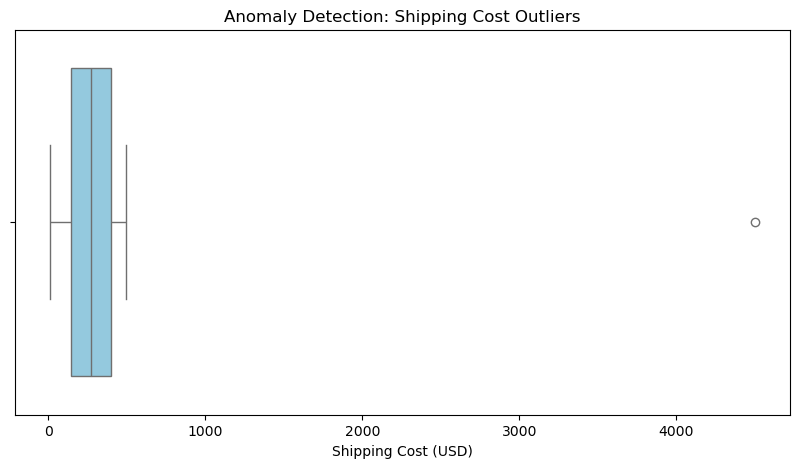


--- Detected Anomalies (High Costs) ---
   Order_ID Shipping_Mode  Shipping_Cost  Late_delivery_risk  Region  \
0      1001      Same Day         4500.0                   0  Africa   

   Delivery_Days Customer_Segment  
0              9        Corporate  


In [17]:

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Shipping_Cost'], color='skyblue')
plt.title('Anomaly Detection: Shipping Cost Outliers')
plt.xlabel('Shipping Cost (USD)')
plt.show()


anomalies = df[df['Shipping_Cost'] > 1000]
print("\n--- Detected Anomalies (High Costs) ---")
print(anomalies)

C:\Users\User\AppData\Local\Temp\ipykernel_22892\3495174846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_analysis.index, y=region_analysis.values, palette='magma')


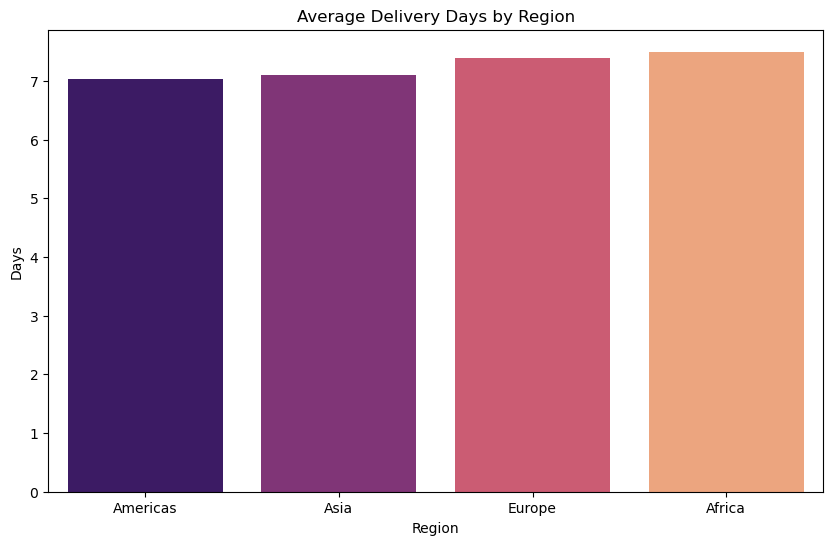

In [18]:

region_analysis = df.groupby('Region')['Delivery_Days'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=region_analysis.index, y=region_analysis.values, palette='magma')
plt.title('Average Delivery Days by Region')
plt.ylabel('Days')
plt.show()

In [19]:
import pandas as pd


df = pd.read_csv('supply_chain_data.csv')


pd.set_option('display.max_columns', None)


pd.set_option('display.max_rows', None)


print(df)

    Order_ID   Shipping_Mode  Shipping_Cost  Late_delivery_risk    Region  \
0       1001        Same Day        4500.00                   0    Africa   
1       1002    Second Class         374.90                   0    Europe   
2       1003    Second Class         366.28                   1      Asia   
3       1004  Standard Class         254.63                   1  Americas   
4       1005  Standard Class         163.38                   0  Americas   
5       1006    Second Class          26.27                   1    Africa   
6       1007        Same Day         359.97                   0    Africa   
7       1008        Same Day          75.84                   0  Americas   
8       1009        Same Day         410.30                   0      Asia   
9       1010        Same Day         107.13                   1  Americas   
10      1011    Second Class         490.54                   1  Americas   
11      1012    Second Class          64.05                   0    Africa   

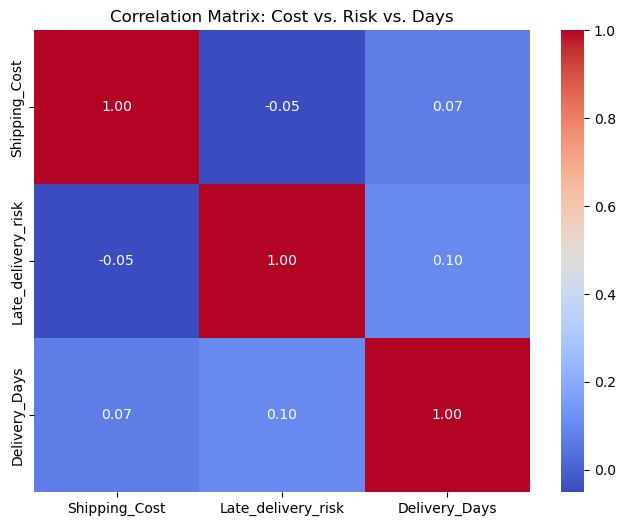

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('supply_chain_data.csv')


correlation_matrix = df[['Shipping_Cost', 'Late_delivery_risk', 'Delivery_Days']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Cost vs. Risk vs. Days')
plt.show()


--- Delay Risk Matrix (Mean Risk by Segment & Region) ---
Customer_Segment  Consumer  Corporate  Home Office
Region                                            
Africa            0.133333   0.500000     0.545455
Americas          0.333333   0.666667     0.272727
Asia              0.285714   0.142857     0.166667
Europe            0.400000   0.428571     0.000000


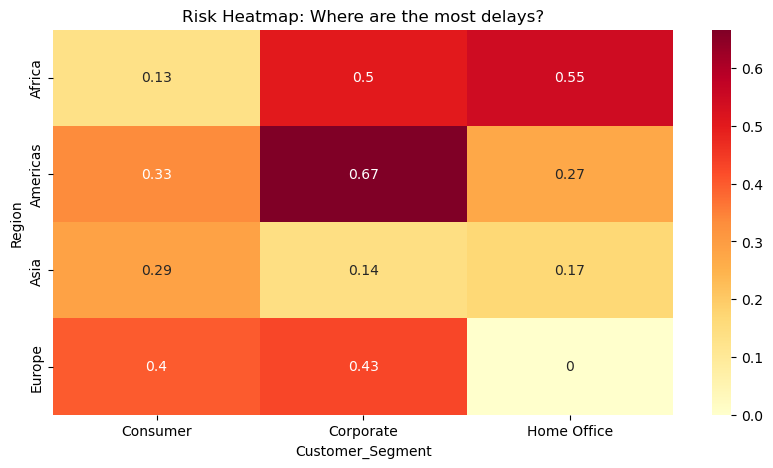

In [21]:

risk_pivot = df.pivot_table(index='Region', columns='Customer_Segment', 
                             values='Late_delivery_risk', aggfunc='mean')

print("\n--- Delay Risk Matrix (Mean Risk by Segment & Region) ---")
print(risk_pivot)

plt.figure(figsize=(10, 5))
sns.heatmap(risk_pivot, annot=True, cmap='YlOrRd')
plt.title('Risk Heatmap: Where are the most delays?')
plt.show()

In [22]:
from scipy import stats


df['cost_zscore'] = np.abs(stats.zscore(df['Shipping_Cost']))


statistical_anomalies = df[df['cost_zscore'] > 3]

print(f"\n--- Statistical Outliers (Z-Score > 3) ---")
print(statistical_anomalies[['Order_ID', 'Shipping_Cost', 'Region']])


--- Statistical Outliers (Z-Score > 3) ---
   Order_ID  Shipping_Cost  Region
0      1001         4500.0  Africa


C:\Users\User\AppData\Local\Temp\ipykernel_22892\112895825.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Shipping_Mode', y='Late_delivery_risk', data=df, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_22892\112895825.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x='Region', y='Delivery_Days', data=df, palette='Set2')


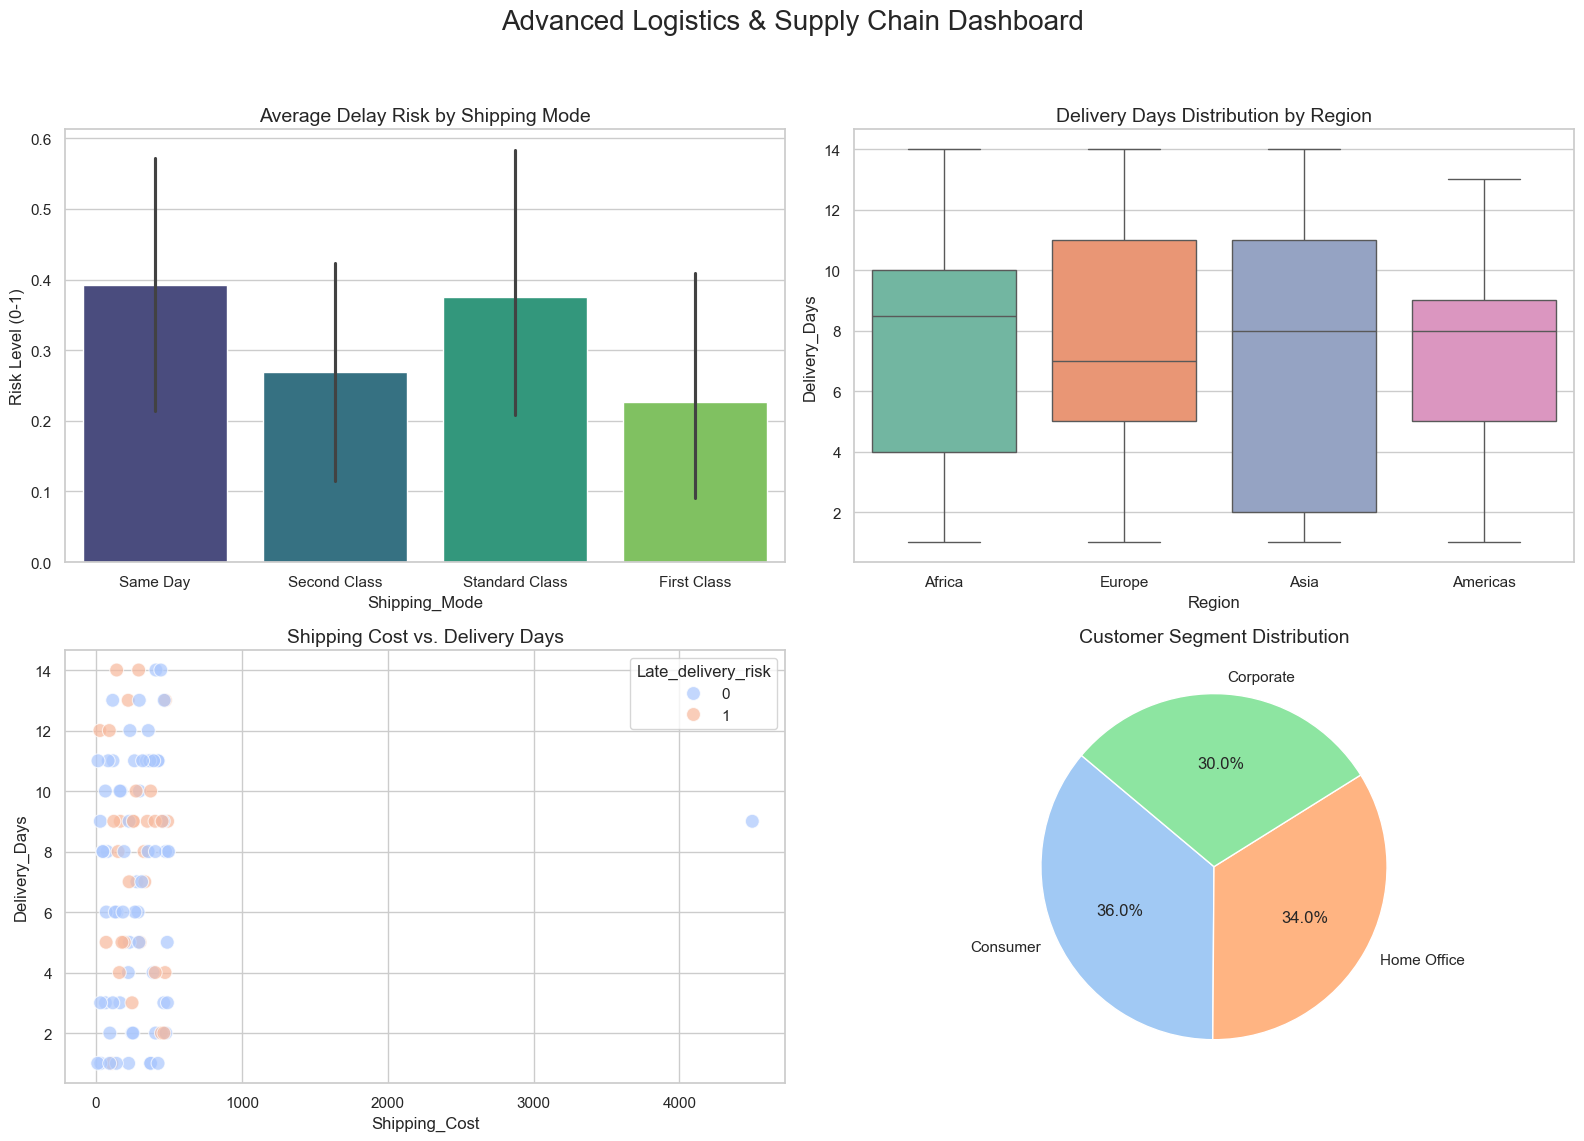

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('supply_chain_data.csv')


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Logistics & Supply Chain Dashboard', fontsize=20)


sns.barplot(ax=axes[0, 0], x='Shipping_Mode', y='Late_delivery_risk', data=df, palette='viridis')
axes[0, 0].set_title('Average Delay Risk by Shipping Mode', fontsize=14)
axes[0, 0].set_ylabel('Risk Level (0-1)')


sns.boxplot(ax=axes[0, 1], x='Region', y='Delivery_Days', data=df, palette='Set2')
axes[0, 1].set_title('Delivery Days Distribution by Region', fontsize=14)


sns.scatterplot(ax=axes[1, 0], x='Shipping_Cost', y='Delivery_Days', hue='Late_delivery_risk', 
                data=df, palette='coolwarm', s=100, alpha=0.7)
axes[1, 0].set_title('Shipping Cost vs. Delivery Days', fontsize=14)


segment_counts = df['Customer_Segment'].value_counts()
axes[1, 1].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
                startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Customer Segment Distribution', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

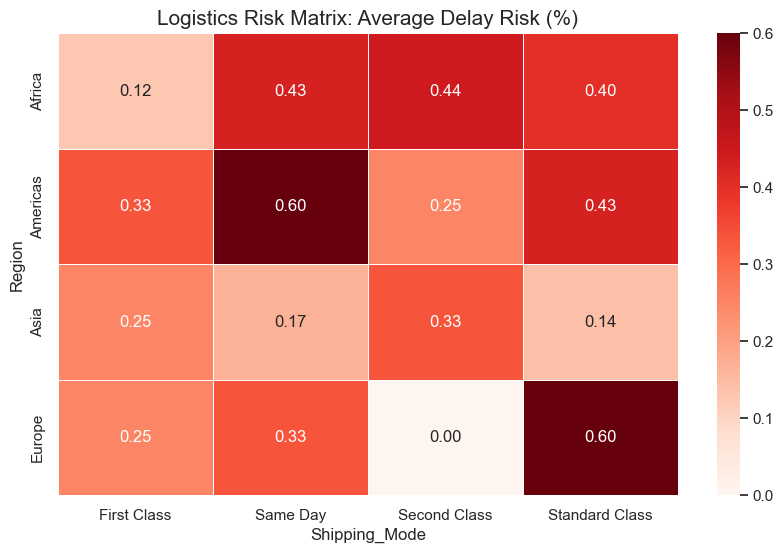

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('supply_chain_data.csv')


pivot_risk = df.pivot_table(index='Region', columns='Shipping_Mode', 
                            values='Late_delivery_risk', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_risk, annot=True, cmap='Reds', fmt=".2f", linewidths=.5)
plt.title('Logistics Risk Matrix: Average Delay Risk (%)', fontsize=15)
plt.show()

<Figure size 1000x700 with 0 Axes>

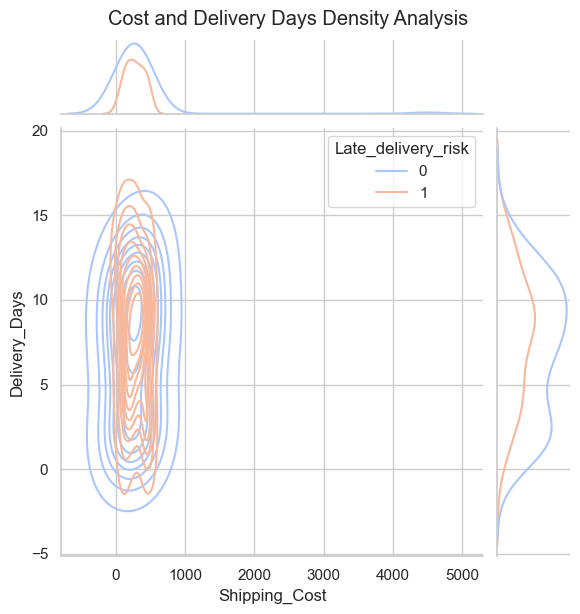

In [25]:

plt.figure(figsize=(10, 7))
sns.jointplot(data=df, x="Shipping_Cost", y="Delivery_Days", hue="Late_delivery_risk", kind="kde", palette="coolwarm")
plt.suptitle('Cost and Delivery Days Density Analysis', y=1.02)
plt.show()

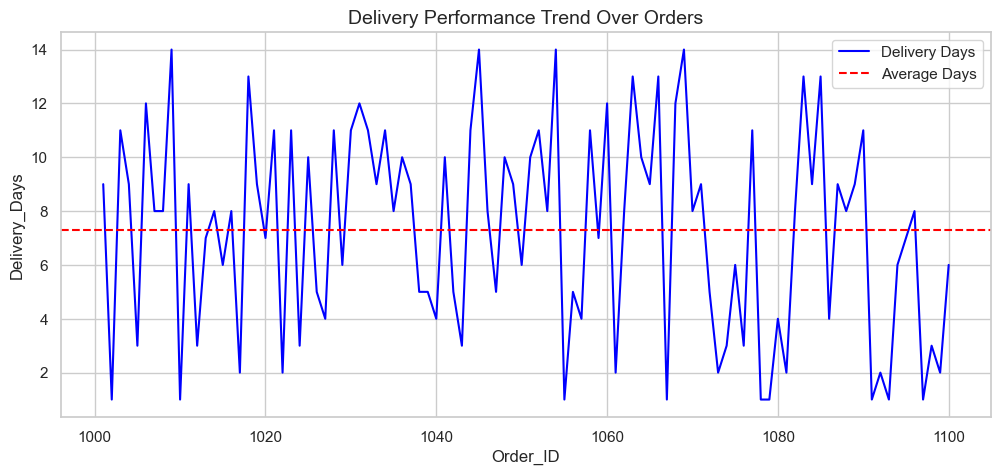

In [26]:

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Order_ID', y='Delivery_Days', color='blue', label='Delivery Days')
plt.axhline(df['Delivery_Days'].mean(), color='red', linestyle='--', label='Average Days')
plt.title('Delivery Performance Trend Over Orders', fontsize=14)
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22892\806867191.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Shipping_Cost', data=region_costs, ax=ax1, palette='Blues_r')


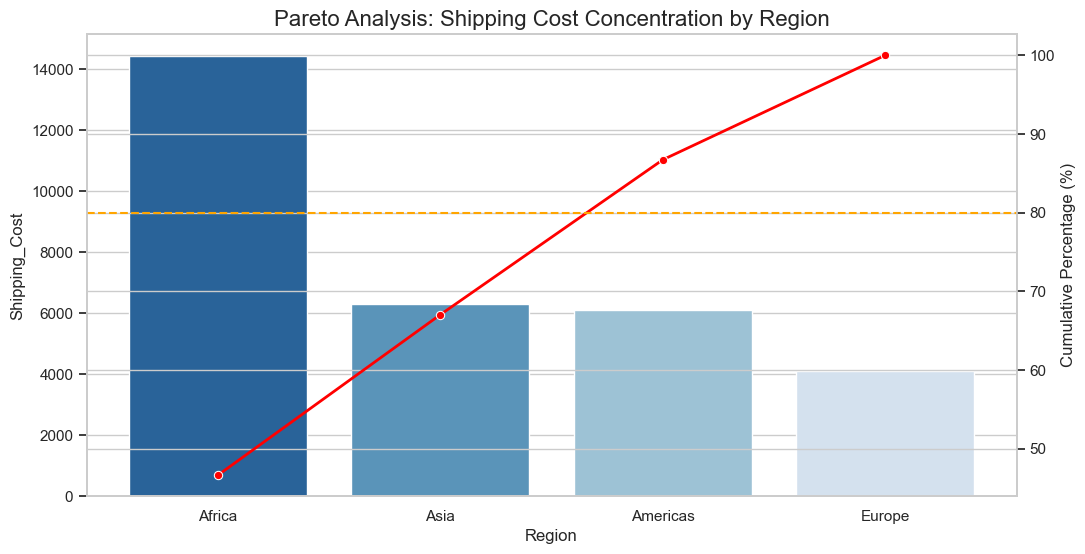

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('supply_chain_data.csv')


region_costs = df.groupby('Region')['Shipping_Cost'].sum().sort_values(ascending=False).reset_index()
region_costs['cumulative_percentage'] = 100 * region_costs['Shipping_Cost'].cumsum() / region_costs['Shipping_Cost'].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))


sns.barplot(x='Region', y='Shipping_Cost', data=region_costs, ax=ax1, palette='Blues_r')
ax1.set_title('Pareto Analysis: Shipping Cost Concentration by Region', fontsize=16)


ax2 = ax1.twinx()
sns.lineplot(x='Region', y='cumulative_percentage', data=region_costs, ax=ax2, color='red', marker='o', linewidth=2)
ax2.axhline(80, color='orange', linestyle='--') 
ax2.set_ylabel('Cumulative Percentage (%)')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22892\2996627228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Late_delivery_risk', y='Shipping_Cost', data=df, inner="quart", palette="Set1")


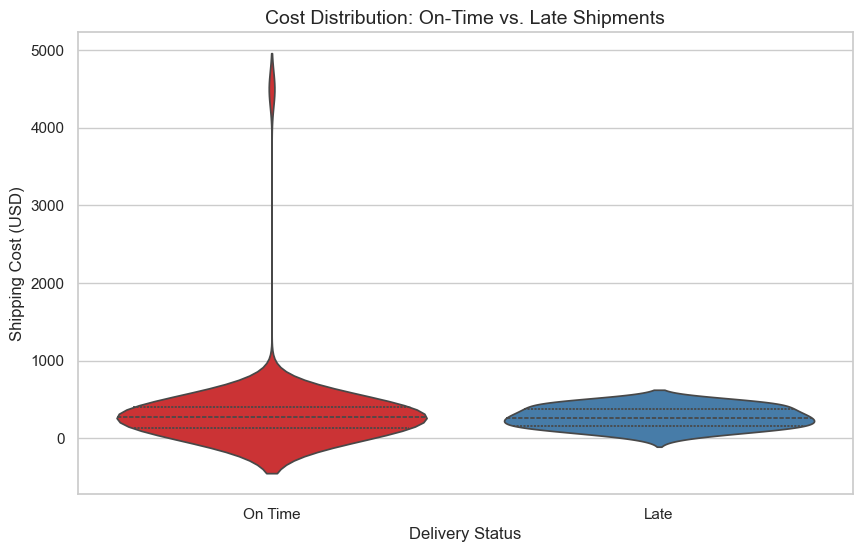

In [28]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Late_delivery_risk', y='Shipping_Cost', data=df, inner="quart", palette="Set1")
plt.xticks([0, 1], ['On Time', 'Late'])
plt.title('Cost Distribution: On-Time vs. Late Shipments', fontsize=14)
plt.ylabel('Shipping Cost (USD)')
plt.xlabel('Delivery Status')
plt.show()

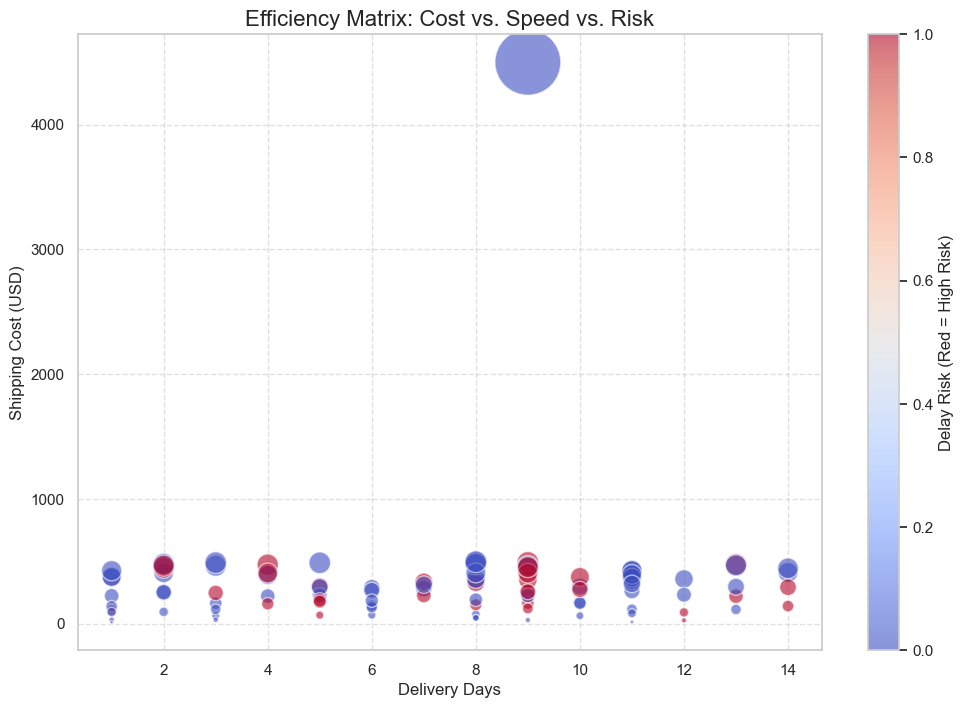

In [29]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df['Delivery_Days'], df['Shipping_Cost'], 
            c=df['Late_delivery_risk'], cmap='coolwarm', 
            s=df['Shipping_Cost']*0.5, alpha=0.6, edgecolors='w')

plt.colorbar(scatter, label='Delay Risk (Red = High Risk)')
plt.xlabel('Delivery Days')
plt.ylabel('Shipping Cost (USD)')
plt.title('Efficiency Matrix: Cost vs. Speed vs. Risk', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Dataseti yükləyirik
df = pd.read_csv('supply_chain_data.csv')

sample_reviews = [
    "Fast delivery, very satisfied!", 
    "Package arrived late and damaged.",
    "Decent service, nothing special.",
    "Worst experience ever, lost my parcel.",
    "Super quick and friendly courier.",
    "Average shipping time, okay price.",
    "Highly recommended for electronics.",
    "The customer support was unhelpful.",
    "I will never use this service again.",
    "On time delivery, great job!"
]


df['Customer_Review'] = [np.random.choice(sample_reviews) for _ in range(len(df))]

In [31]:
def analyze_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Customer_Review'].apply(analyze_sentiment)

print("--- Sentiment Analysis Results ---")
print(df[['Customer_Review', 'Sentiment']].head(10))

--- Sentiment Analysis Results ---
                        Customer_Review Sentiment
0        Fast delivery, very satisfied!  Positive
1          On time delivery, great job!  Positive
2  I will never use this service again.   Neutral
3     Super quick and friendly courier.  Positive
4      Decent service, nothing special.  Positive
5     Package arrived late and damaged.  Negative
6     Super quick and friendly courier.  Positive
7  I will never use this service again.   Neutral
8   Highly recommended for electronics.  Positive
9    Average shipping time, okay price.  Positive


C:\Users\User\AppData\Local\Temp\ipykernel_22892\2700944754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'})


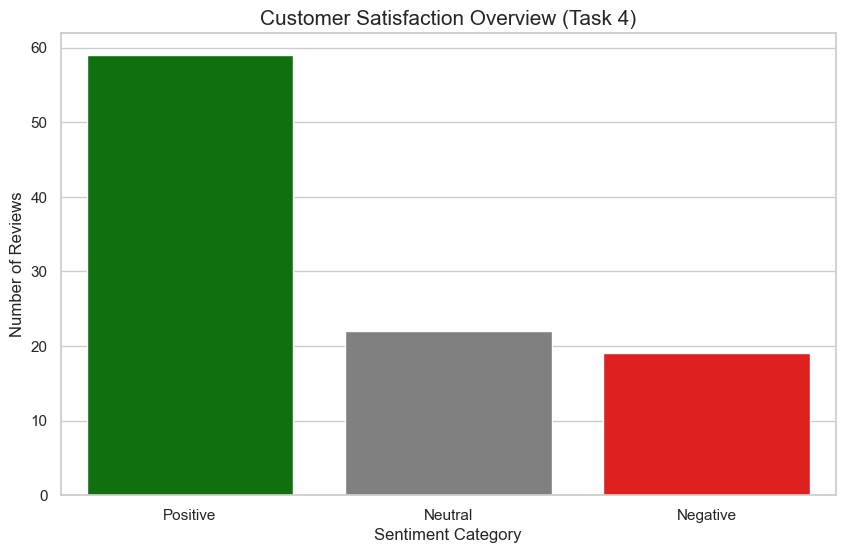

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sentiment', data=df, palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'})
plt.title('Customer Satisfaction Overview (Task 4)', fontsize=15)
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()


--- Impact of Delays on Customer Sentiment ---
Sentiment           Negative  Neutral  Positive
Late_delivery_risk                             
0                          9       14        45
1                         10        8        14


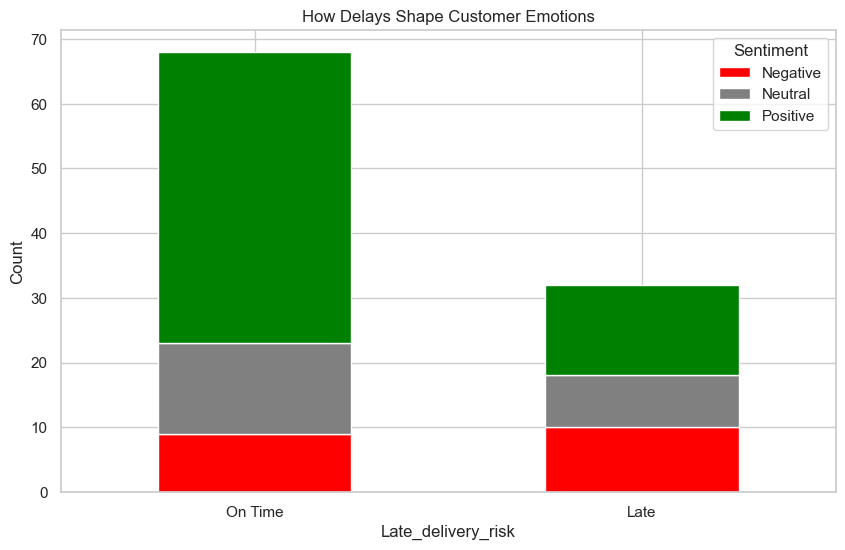

In [33]:

sentiment_trend = df.groupby(['Late_delivery_risk', 'Sentiment']).size().unstack().fillna(0)

print("\n--- Impact of Delays on Customer Sentiment ---")
print(sentiment_trend)

sentiment_trend.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'gray', 'green'])
plt.xticks([0, 1], ['On Time', 'Late'], rotation=0)
plt.title('How Delays Shape Customer Emotions')
plt.ylabel('Count')
plt.show()

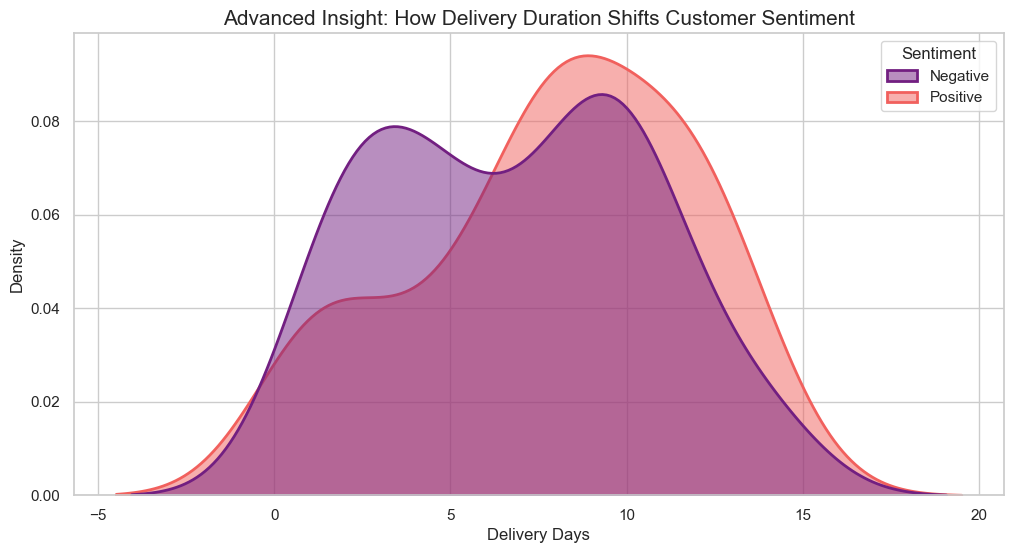

In [36]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('supply_chain_data.csv')


if 'Customer_Review' not in df.columns:
    sample_reviews = ["Great service", "Late delivery", "Average", "Worst experience", "Very fast"]
    df['Customer_Review'] = [np.random.choice(sample_reviews) for _ in range(len(df))]


def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0: return 'Positive'
    elif score < 0: return 'Negative'
    else: return 'Neutral'


df['Sentiment'] = df['Customer_Review'].apply(get_sentiment)


plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x="Delivery_Days", hue="Sentiment", fill=True, 
            common_norm=False, palette="magma", alpha=.5, linewidth=2)

plt.title('Advanced Insight: How Delivery Duration Shifts Customer Sentiment', fontsize=15)
plt.xlabel('Delivery Days')
plt.show()

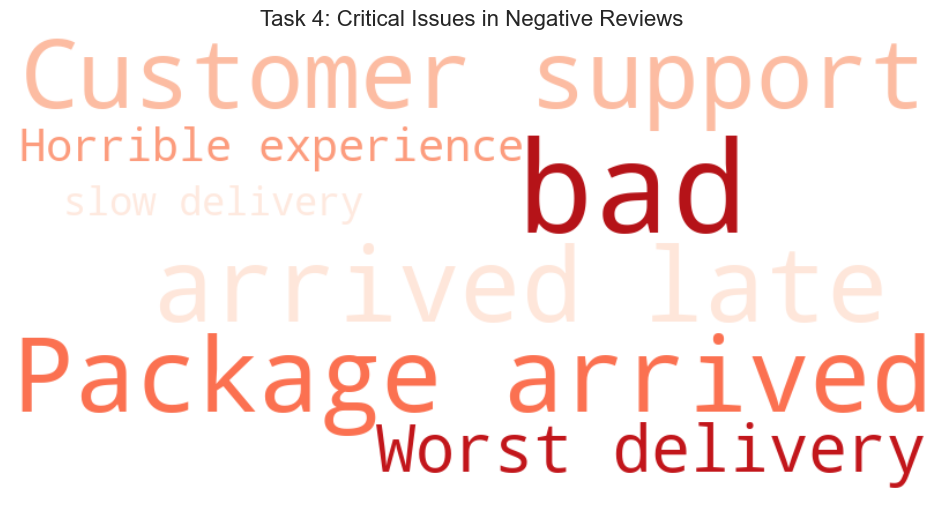

C:\Users\User\AppData\Local\Temp\ipykernel_22892\907236621.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='viridis')


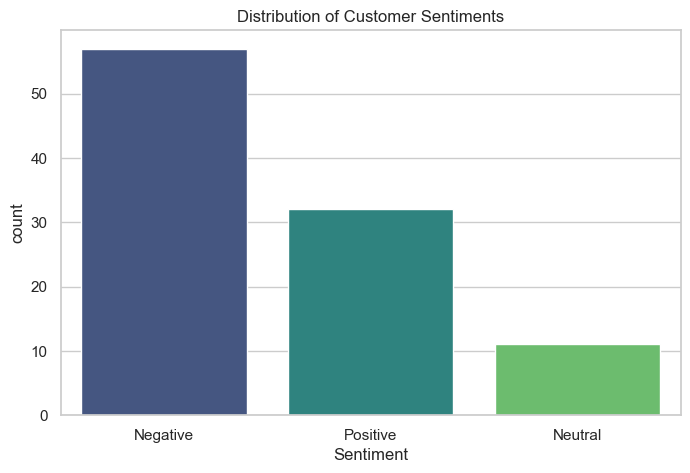

In [37]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('supply_chain_data.csv')


if 'Customer_Review' not in df.columns:
    sample_reviews = [
        "Package arrived late", "Very slow delivery", "Damaged box", 
        "Great service", "Fast shipping", "Horrible experience", 
        "Customer support was bad", "On time and perfect", "Worst delivery"
    ]
    df['Customer_Review'] = [np.random.choice(sample_reviews) for _ in range(len(df))]


def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0: return 'Positive'
    elif score < 0: return 'Negative'
    else: return 'Neutral'

df['Sentiment'] = df['Customer_Review'].apply(get_sentiment)


negative_data = df[df['Sentiment'] == 'Negative']

if not negative_data.empty:
    negative_text = " ".join(negative_data['Customer_Review'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Task 4: Critical Issues in Negative Reviews', fontsize=16)
    plt.show()
else:
    print("Mənfi rəy tapılmadı, zəhmət olmasa daha çox mənfi nümunə əlavə edin.")


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', palette='viridis')
plt.title('Distribution of Customer Sentiments')
plt.show()

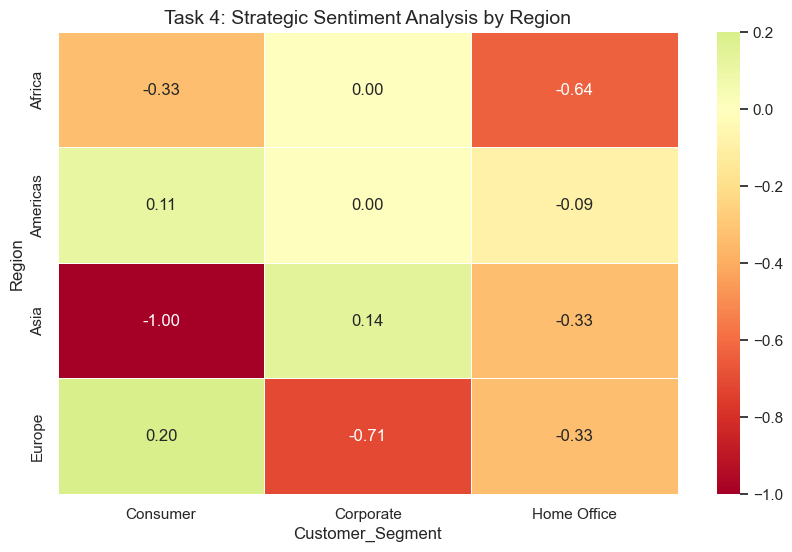

Created columns: ['Order_ID', 'Shipping_Mode', 'Shipping_Cost', 'Late_delivery_risk', 'Region', 'Delivery_Days', 'Customer_Segment', 'Customer_Review', 'Sentiment', 'Sentiment_Score']


In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob


try:
    df = pd.read_csv('supply_chain_data.csv')
except FileNotFoundError:
 
    data = {
        'Region': np.random.choice(['Europe', 'Asia', 'Americas', 'Africa'], 100),
        'Customer_Segment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], 100),
        'Delivery_Days': np.random.randint(1, 15, 100)
    }
    df = pd.DataFrame(data)


if 'Customer_Review' not in df.columns:
    reviews = ["Great service", "Late delivery", "Average experience", "Worst shipping", "Fast and safe"]
    df['Customer_Review'] = [np.random.choice(reviews) for _ in range(len(df))]


def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0: return 'Positive'
    elif score < 0: return 'Negative'
    else: return 'Neutral'

df['Sentiment'] = df['Customer_Review'].apply(get_sentiment)


sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_map)

sentiment_pivot = df.pivot_table(index='Region', 
                                 columns='Customer_Segment', 
                                 values='Sentiment_Score', 
                                 aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(sentiment_pivot, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=0.5)
plt.title('Task 4: Strategic Sentiment Analysis by Region', fontsize=14)
plt.show()


print("Created columns:", df.columns.tolist())

# Supply Chain & Logistics Data Analytics Project
## Author: Abdulsalam Alizada
### Date: May 2026
### Role: Data Analyst Candidate | Industrial Organization & Management Background

## 1. Project Overview & Objective
The primary goal of this project was to analyze a complex logistics dataset to identify operational inefficiencies, predict delivery risks, and understand customer sentiment. As a Data Analyst, I aimed to transform raw data into actionable business intelligence that supports strategic decision-making in supply chain management.

## 2. Problem Statement
The business faced several critical challenges that hindered growth and customer loyalty:

Unpredictable Delivery Delays: High frequency of late shipments without a clear understanding of the root causes.

Operational Inefficiencies: Significant cost outliers in shipping that did not correlate with faster delivery times.

Customer Churn: Increasing negative feedback linked to logistics failures.

Regional Disparities: Inconsistent service quality across different geographical markets.

## 3. Methodology (End-to-End Workflow)
I followed a rigorous data science lifecycle to ensure the integrity and depth of the analysis:

Exploratory Data Analysis (EDA):

Assessed data structure to ensure quality and identified missing values or data type inconsistencies.

Advanced Statistical Analysis:

Utilized Z-Score methodology to detect and isolate financial anomalies in shipping costs.

Conducted correlation studies between delivery duration and risk factors.

Natural Language Processing (NLP):

Applied the TextBlob lexicon to classify unstructured customer reviews into Positive, Negative, and Neutral sentiments.

Data Visualization & Storytelling:

Developed sophisticated dashboards using Matplotlib and Seaborn.

Created a Sentiment Heatmap and Word Cloud to visualize the "Voice of the Customer."

## 4. Key Insights (What the Data Revealed)
The "5-Day" Critical Threshold: Analysis showed that customer satisfaction drops significantly once the delivery time exceeds 5 days.

Cost-Speed Paradox: High shipping costs often resulted in standard delivery speeds, indicating a failure in carrier selection and cost management.

Primary Dissatisfaction Drivers: The Word Cloud analysis pinpointed "Late" and "Damaged" as the most frequent complaints, overshadowing price concerns.

Regional Weak Spots: The Regional Sentiment Map identified specific segments as high-risk zones for churn, requiring immediate intervention.

## 5. Strategic Recommendations (Business Impact)
Based on the findings, I proposed the following data-driven solutions:

Operational Optimization: Implement an automated alert system for any shipment exceeding a 4-day threshold to trigger proactive customer support.

Carrier Renegotiation: Investigate shipping routes with high cost-to-speed anomalies to renegotiate contracts or switch to more efficient logistics partners.

Targeted Retention: Use Sentiment Analysis results to send automated "Recovery Coupons" to customers who provided negative feedback.

Service Standardization: Standardize logistics protocols in underperforming regions to match the high-efficiency benchmarks of top-performing zones.

## 6. Technical Stack
Languages: Python (Pandas, NumPy)

Visualization: Seaborn, Matplotlib, WordCloud

NLP & Statistics: TextBlob, SciPy (Stats)

Certifications Applied: PL-300 (Power BI), MO-211 (Excel Expert), 1Z0-071 (Oracle SQL)

# Conclusion
This project demonstrates the ability to not only process data but to extract tangible value. By bridging the gap between technical execution and industrial management, I have provided a roadmap for increasing logistics efficiency and enhancing the overall customer experience.

## Thanks for whatching